# Cell-Type Annotation with LLM: A Step-by-Step Tutorial

This notebook demonstrates how to perform cell-type annotation on spatial transcriptomics data (Xenium, FFPE human breast) using Scanpy and an LLM (e.g., OpenAI GPT) for automatic cluster labeling. You’ll learn how to:

1. Set up the environment and load a sample dataset.
2. Cluster cells with Scanpy (Leiden) and extract top marker genes.
3. Use an LLM to assign cell-type labels to each cluster.
4. Visualize the annotated results (UMAP) and inspect top marker genes per annotated cell type.

Replace `API_KEY` with your own OpenAI key to run LLM annotation.

In [1]:
# Cell 1: Notebook Setup
# ----------------------

# Install requirements if necessary (uncomment if needed)
# !pip install scanpy openai anndata tic

import scanpy as sc
import warnings
warnings.filterwarnings("ignore")

# Set Scanpy verbosity and plotting defaults
sc.settings.verbosity = 2
sc.set_figure_params(figsize=(5, 5), dpi=100)


## Load the Dataset

You can load your own data (e.g., `adata = sc.read_h5ad("path/to/file.h5ad")`), or use a built-in example. Here, we use the `tic.data.load_xenium_dataset` helper to fetch a sample Xenium kidney cancer dataset.

In [2]:
# Cell 2: Load Dataset
# --------------------

from tic.data import load_xenium_dataset

adata = load_xenium_dataset(name='xenium_pancreas_cancer')
adata

# Provide a description of the dataset to include in the LLM prompt
DATASET_DESCRIPTION = """
Xenium In Situ gene expression profiling of human pancreatic cancer (adenocarcinoma, Grade I–II) using the Xenium Human Multi-Tissue and Cancer Panel.
A formalin-fixed paraffin-embedded (FFPE) tissue block was obtained from AcePix Biosciences, derived from a pancreatic tumor specimen containing approximately 50% tumor content.
Tissue preparation followed the demonstrated protocols Xenium In Situ for FFPE - Tissue Preparation Guide (CG000578) and Xenium In Situ for FFPE Tissues – Deparaffinization & Decrosslinking (CG000580).
Gene expression profiling was performed using the Xenium Human Multi-Tissue and Cancer Panel (377 genes), designed by 10x Genomics. The panel includes:
- 93 genes optimized for tissue-specific detection across organs including pancreas, breast, lung, kidney, liver, colon, heart, skin, and lymph node.
- 284 core genes representing common immune and cancer-related markers.
An additional 97 custom genes were included to evaluate crowding effects from high expressers.
The experiment was run on the Xenium Analyzer (User Guide CG000584) with Xenium Onboard Analysis version 1.6.0.
Summary metrics:
- Cells detected: 190,965
- Median transcripts per cell: 114
- Decoded transcripts per 100 µm²: 135.2
- Total high-quality transcripts: 23,926,081
- Tissue region area: 22,386,228 µm²
Post-instrument H&E staining followed CG000613, and IF staining was conducted using primary antibodies (CD20, TROP2, PPY) and Alexa-conjugated secondaries, followed by imaging with a Zeiss Axioimager and image registration via Xenium Explorer.
This dataset enables spatial analysis of gene expression in pancreatic adenocarcinoma, supporting studies of tumor microenvironment, immune infiltration, and spatial biomarker localization.
"""


Xenium dataset 'xenium_pancreas_cancer' already exists at /Users/zhangjiahao/.cache/tic/xenium_pancreas_cancer
2025-06-05 12:51:58,971 | INFO     | tic.data.xenium.download | Xenium dataset 'xenium_pancreas_cancer' already exists at /Users/zhangjiahao/.cache/tic/xenium_pancreas_cancer


reading /Users/zhangjiahao/.cache/tic/xenium_pancreas_cancer/cell_feature_matrix.h5
 (0:00:00)


2025-06-05 12:51:59,673 INFO Loaded xenium_pancreas_cancer: 190965 cells * 538 genes.
2025-06-05 12:51:59,673 | INFO     | tic.data.xenium.loader | Loaded xenium_pancreas_cancer: 190965 cells * 538 genes.


## Run Full Annotation Pipeline

This step performs:
1. Preprocessing (filtering, normalization, PCA, neighbors, Leiden).
2. Ranking top marker genes per Leiden cluster.
3. Querying an LLM to assign cell-type labels to each cluster.
4. Mapping those labels back to each cell in `adata.obs['pred_cell_type']`.

Make sure to set your `API_KEY` (e.g., in `utils.config.API_KEY`).

In [3]:
# Cell 3: Run Full Annotation Pipeline
# ------------------------------------

from tic.annotation import annotate_adata
from utils.config import API_KEY  # Replace with your own key

adata_pred, cluster_annotation = annotate_adata(
    adata=adata,
    assign_params={
        "min_cells": 0,
        "min_genes": 0,
        "n_pca": 50,
        "n_neighbors": 15,
        "resolution": 2.0,
        "n_filter_highly_variable_genes": 2000,
    },
    llm_model_name="openai",
    llm_kwargs={"api_key": API_KEY, "mirror": True},
    dataset_description=(
        DATASET_DESCRIPTION +
        "This dataset contains tumor cells. Please ensure at least one cluster is annotated as tumor."
    ),
    groupby="leiden",
    rank_genes_groups_method="t-test",
    n_genes=10,
    copy=True,
    return_cluster_annotation=True,
)

import json
print("Cluster → Assigned Cell Type:")
print(json.dumps(cluster_annotation, indent=2))


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
`n_top_genes` > `adata.n_var`, returning all genes.
    finished (0:00:00)
computing PCA
    with n_comps=50
    finished (0:00:03)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished (0:00:22)
running Leiden clustering
    finished (0:06:21)
computing UMAP
    finished (0:01:17)
ranking genes


... storing 'group' as categorical
... storing 'cell_type' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical


    finished (0:00:03)


2025-06-05 13:00:28,587 INFO Saved cell-type cache to /Users/zhangjiahao/.cache/tic/xenium_pancreas_cancer/xenium_pancreas_cancer_llm_cell_types.parquet
2025-06-05 13:00:28,587 | INFO     | tic.annotation.api | Saved cell-type cache to /Users/zhangjiahao/.cache/tic/xenium_pancreas_cancer/xenium_pancreas_cancer_llm_cell_types.parquet


Cluster → Assigned Cell Type:
{
  "0": {
    "assigned_cell_type": "Acinar cells",
    "reasoning": "Top markers include AMY2A (pancreatic amylase, acinar specific), ANPEP (expressed in exocrine pancreas), and GATM\u2014all classically expressed in exocrine/acinar pancreas. AQP8 and RNASE1 are also linked to exocrine function."
  },
  "1": {
    "assigned_cell_type": "Ductal cells",
    "reasoning": "Markers like CFTR (cystic fibrosis transmembrane conductance regulator), EPCAM (epithelial marker), and FSTL3 are typically enriched in pancreatic ductal epithelial cells. CFB, BIRC3, CXCL6, and CXCL2 are often upregulated in tumor/ductal epithelial settings."
  },
  "2": {
    "assigned_cell_type": "T cells",
    "reasoning": "Markers such as PTPRC (CD45, pan-leukocyte), IL7R (T cell marker), and TRAC (T cell receptor alpha chain) indicate T lymphocytes. CXCR4 and CCL5 support T cell identity."
  },
  "3": {
    "assigned_cell_type": "Macrophages",
    "reasoning": "Key markers include CD

## Visualize Annotation Results

Plot UMAP embeddings colored by:
1. Original Leiden cluster (`adata.obs['leiden']`).
2. LLM-predicted cell type (`adata.obs['pred_cell_type']`).

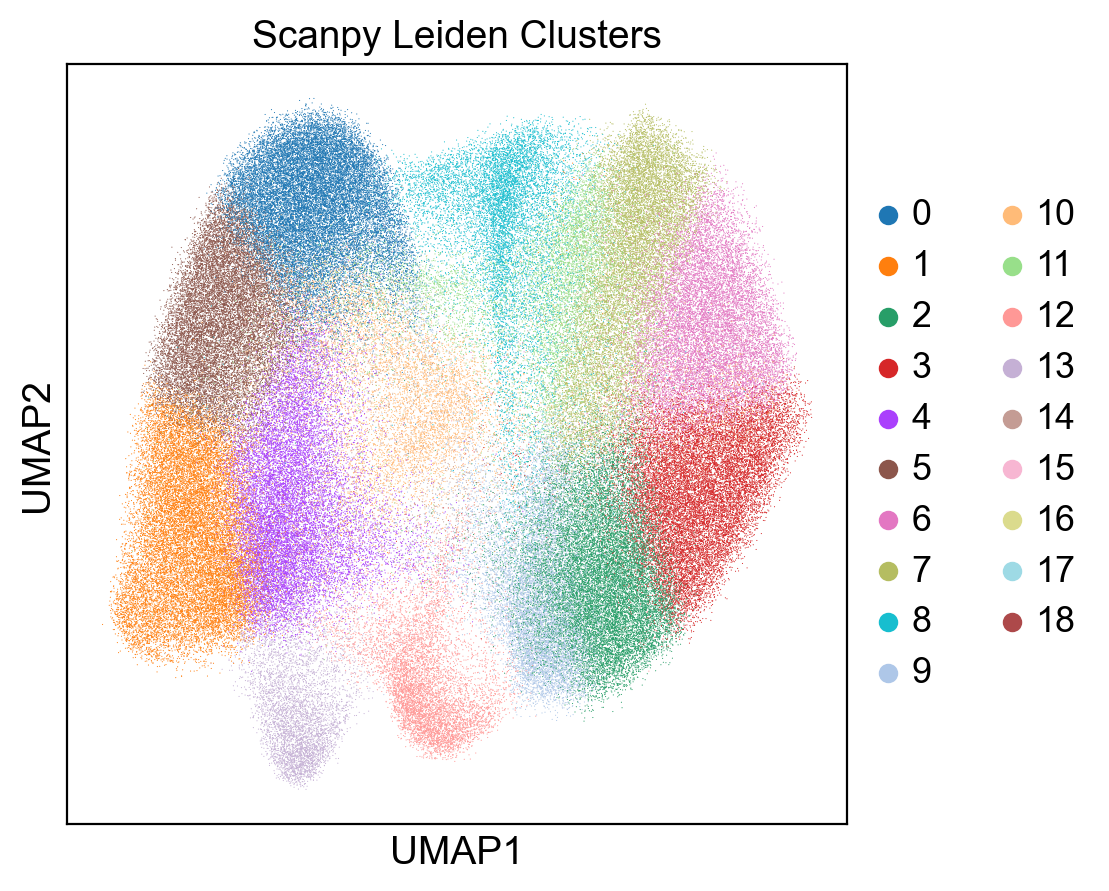

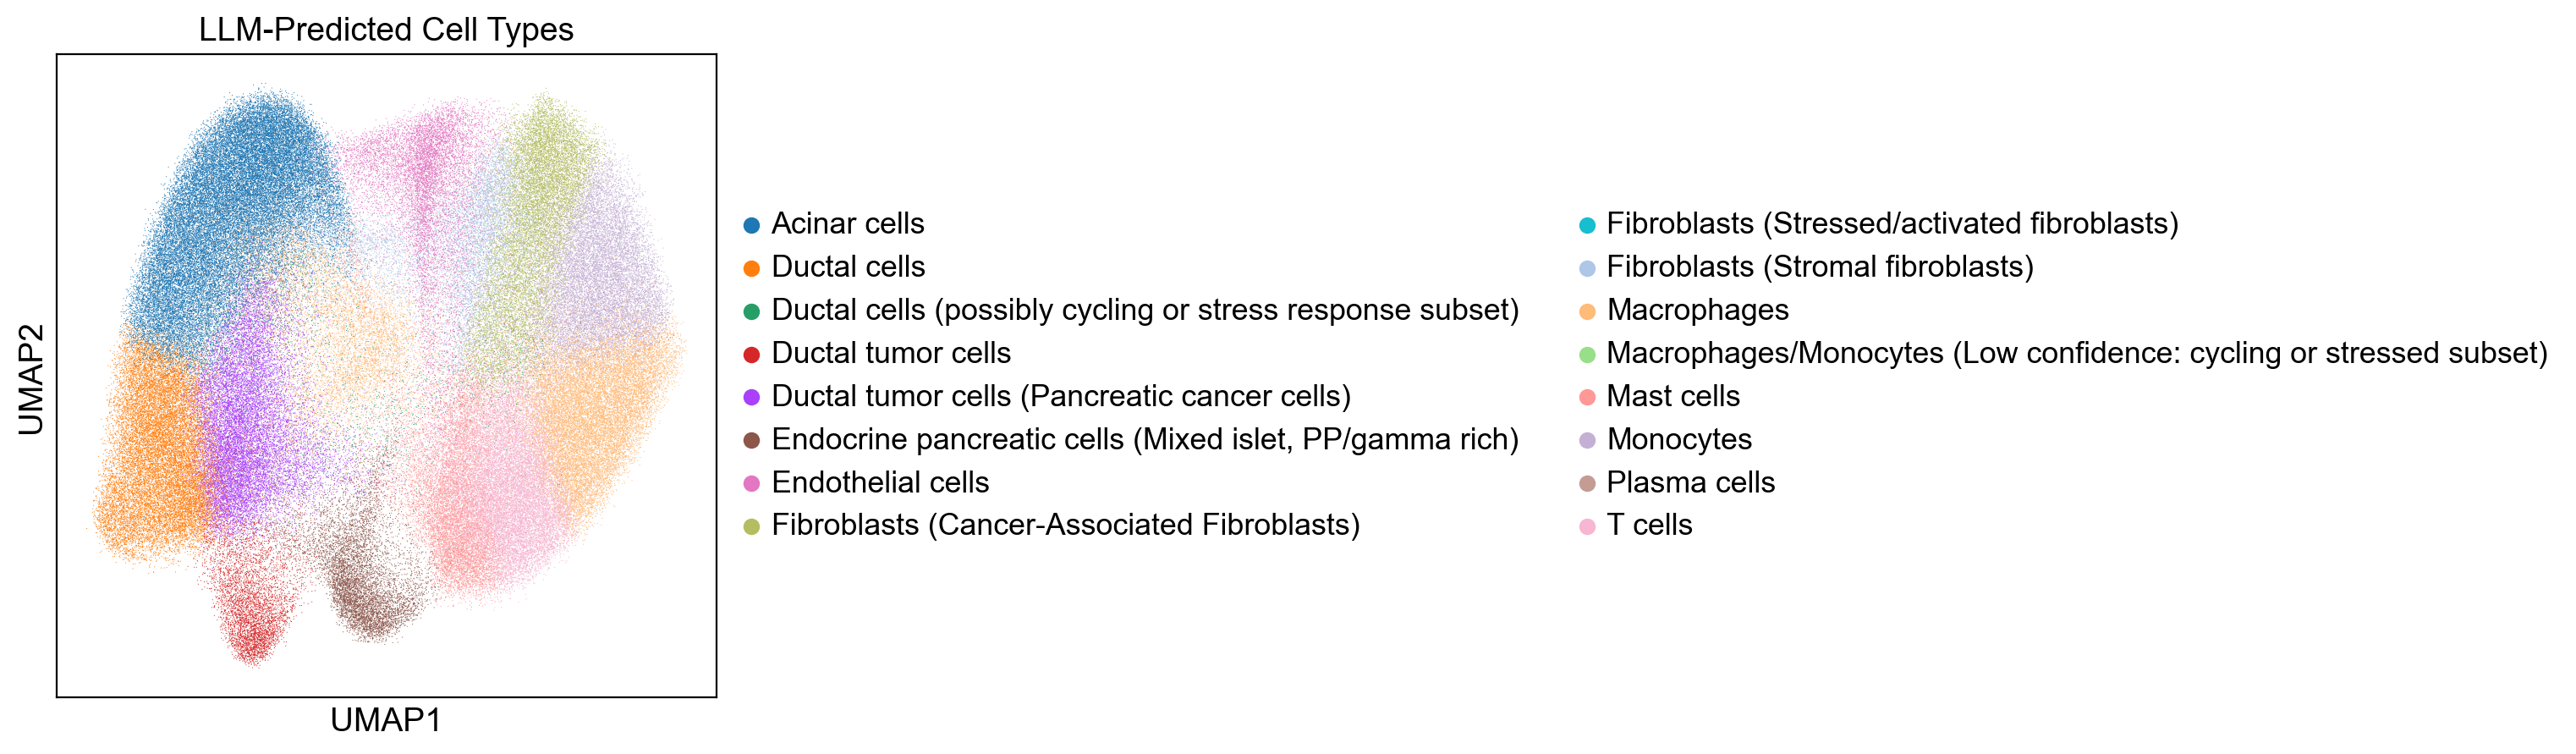

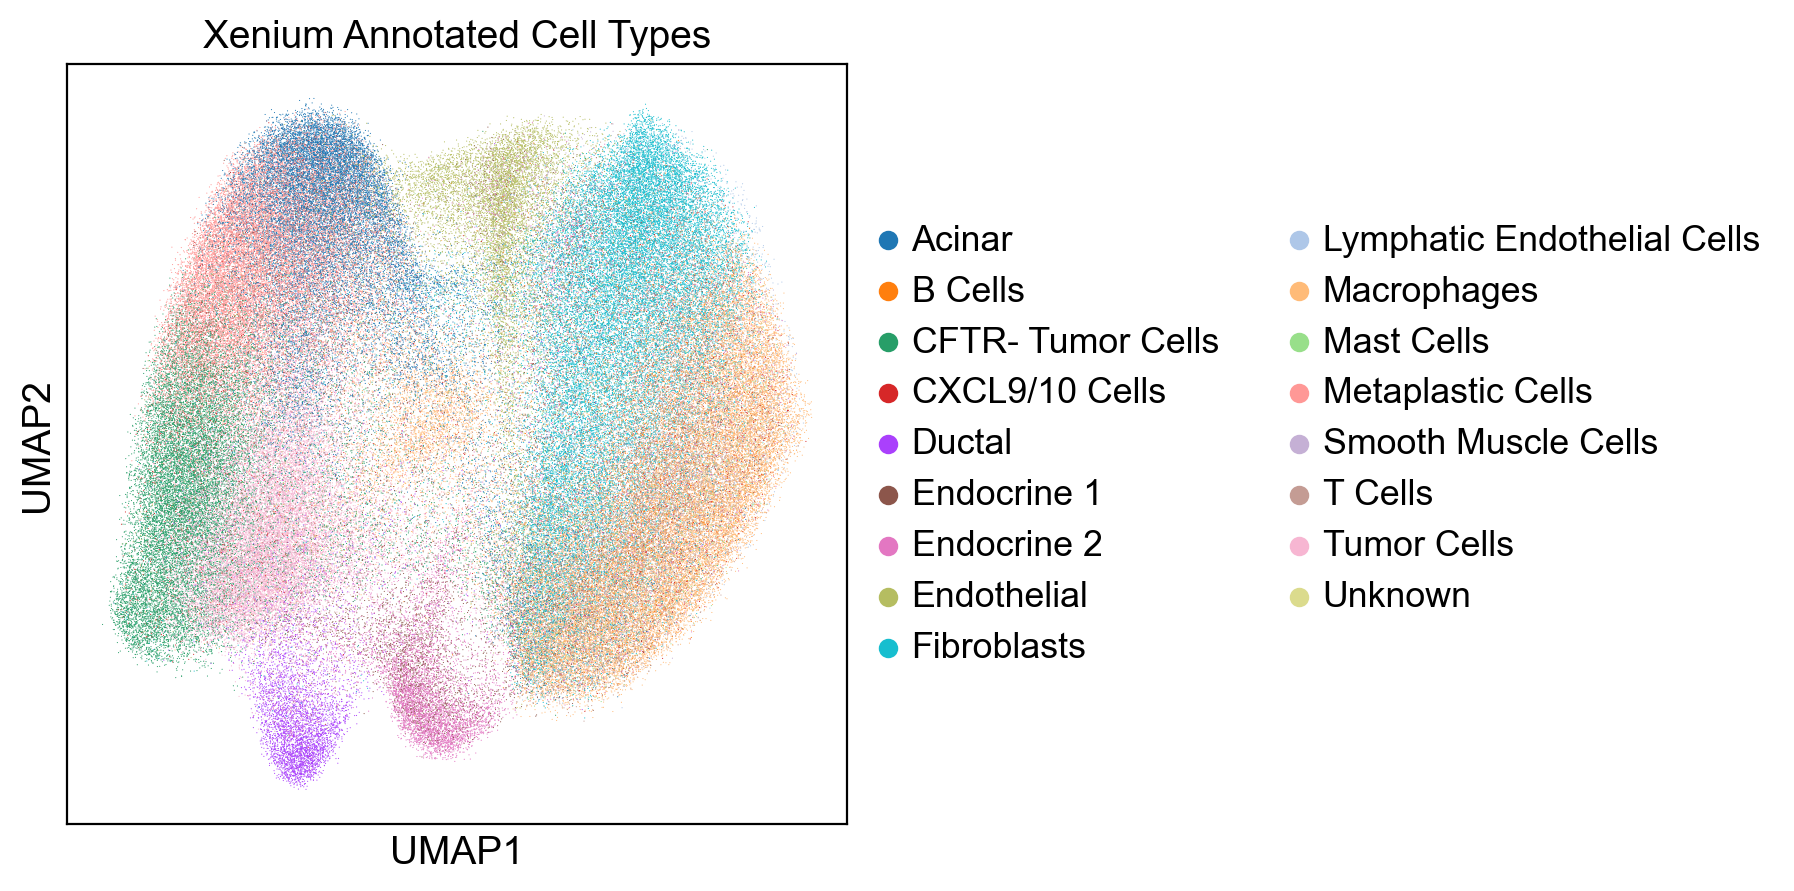

In [10]:
# Cell 4: Visualize Annotation Results
# ------------------------------------

# Plot UMAP colored by original Leiden clusters
sc.pl.umap(adata_pred, color=["leiden"], title="Scanpy Leiden Clusters")

# Plot UMAP colored by LLM-predicted cell types
sc.pl.umap(adata_pred, color=["pred_cell_type"], title="LLM-Predicted Cell Types")

# Plot UMAP colored by xenium ground truth cell types
sc.pl.umap(adata_pred, color=["cell_type"], title="Xenium Annotated Cell Types")


In [14]:
from tic.metrics.annotation import evaluate_cell_type_mapping
from tic.metrics.annotation import plot_aligned_confusion_matrix

results = evaluate_cell_type_mapping(
    adata=adata_pred,
    true_key="cell_type",
    pred_key="pred_cell_type",
    mapped_key="pred_cell_type_mapped",
    return_mapping=True,
    verbose=True,
)

=== Label Mapping (pred → true) ===
Mast cells                     → Acinar
Plasma cells                   → B Cells
Ductal cells                   → CFTR- Tumor Cells
Macrophages/Monocytes (Low confidence: cycling or stressed subset) → CXCL9/10 Cells
Ductal tumor cells             → Ductal
Fibroblasts (Stromal fibroblasts) → Endocrine 1
Endocrine pancreatic cells (Mixed islet, PP/gamma rich) → Endocrine 2
Endothelial cells              → Endothelial
Fibroblasts (Cancer-Associated Fibroblasts) → Fibroblasts
Monocytes                      → Lymphatic Endothelial Cells
Macrophages                    → Macrophages
Ductal cells (possibly cycling or stress response subset) → Mast Cells
Acinar cells                   → Metaplastic Cells
Fibroblasts (Stressed/activated fibroblasts) → Smooth Muscle Cells
T cells                        → T Cells
Ductal tumor cells (Pancreatic cancer cells) → Tumor Cells

=== Classification Report (after alignment) ===
                             precision    r

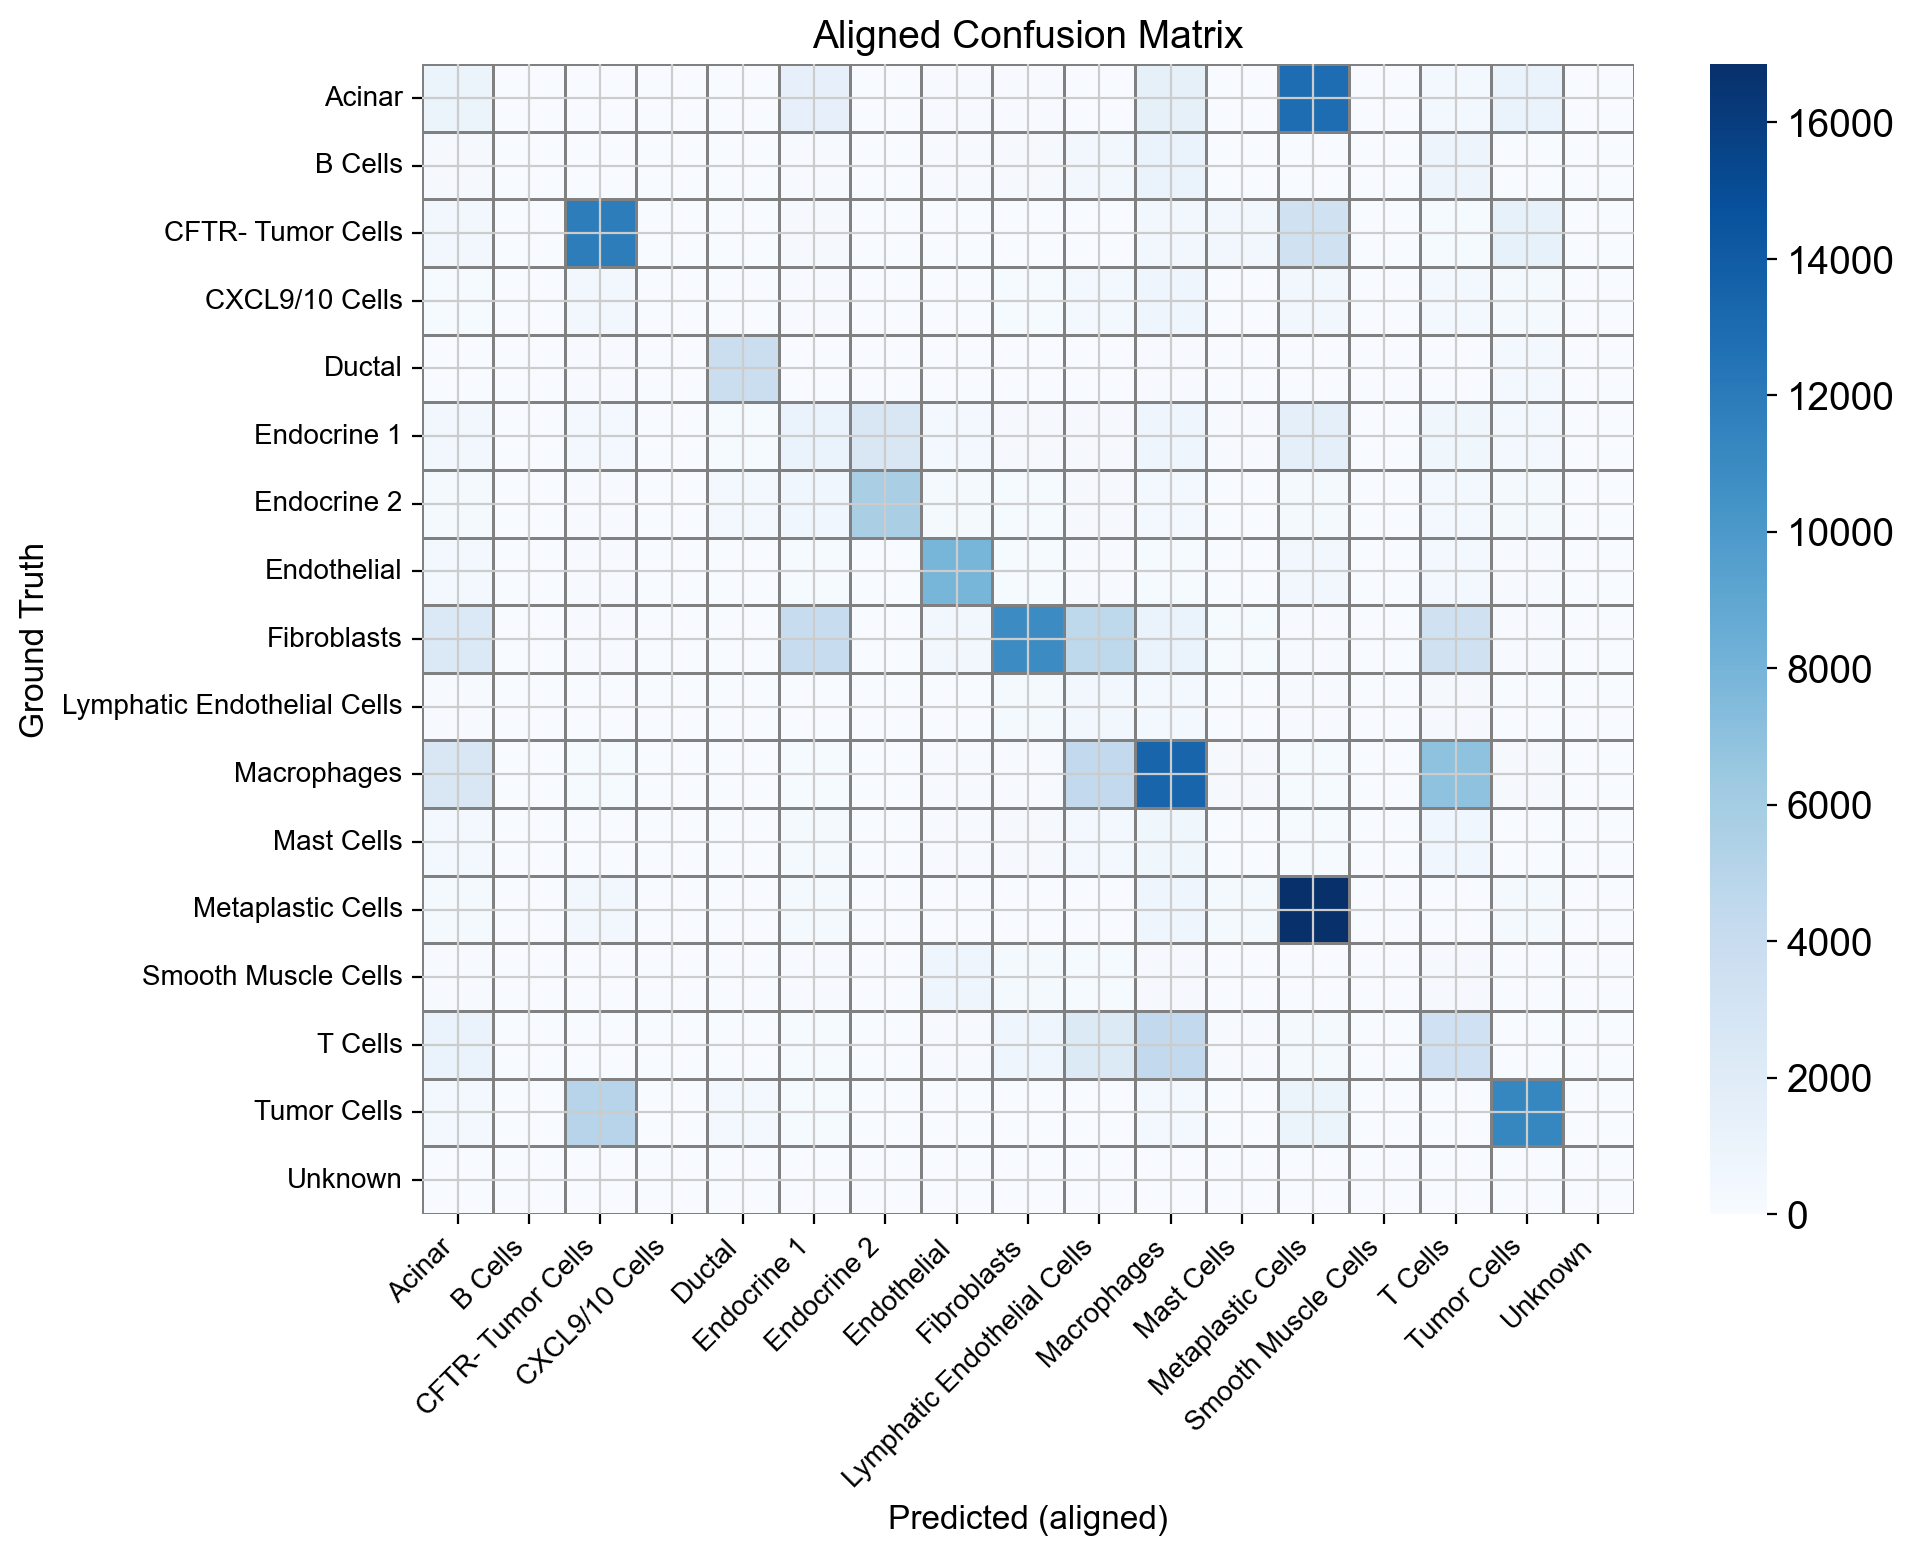

In [16]:
# `adata.obs["pred_cell_type_mapped"]` exists.
plot_aligned_confusion_matrix(
    adata=adata_pred,
    true_key="cell_type",
    mapped_key="pred_cell_type_mapped",
    figsize=(10, 8),
    cmap="Blues",
    annotate=False,
    fmt="d",
    xlabel="Predicted (aligned)",
    ylabel="Ground Truth",
    title="Aligned Confusion Matrix",
    xtick_rotation=45,
    save_path="aligned_confusion_matrix.png",  # or None
)

## Rank Marker Genes by Predicted Cell Type

Now that each cell has a `pred_cell_type` label, let’s re-rank marker genes across those groups. This lets us see the top genes per annotated cell type rather than per Leiden cluster.

In [5]:
# Cell 5: Rank Genes by Predicted Cell Type
# ------------------------------------------

n_genes = 5  # number of top genes per cell type to extract
sc.tl.rank_genes_groups(
    adata_pred,
    groupby="pred_cell_type",
    method="t-test",         # or "wilcoxon", etc.
    n_genes=n_genes,
    key_added="rank_genes_by_pred"  # stored in adata_pred.uns
)


ranking genes
    finished (0:00:02)


## Build a DataFrame of Top Genes + Scores

Extract the `names` and `scores` from `adata_pred.uns['rank_genes_by_pred']`, then combine into a single DataFrame for easy inspection.

In [6]:
# Cell 6: Extract Top Genes into a Pandas DataFrame
# -------------------------------------------------

import pandas as pd

# Grab the Scanpy result object
result = adata_pred.uns["rank_genes_by_pred"]
cell_types = result["names"].dtype.names  # tuple of each predicted cell_type

dfs = []
for ct in cell_types:
    genes = result["names"][ct][:n_genes].tolist()
    scores = result["scores"][ct][:n_genes].tolist()
    df_temp = pd.DataFrame({
        "cell_type": ct,
        "gene": genes,
        "score": scores
    })
    dfs.append(df_temp)

df_top = pd.concat(dfs, ignore_index=True)
df_top


,cell_type,gene,score
0,Acinar cells,GATM,407.114899
1,Acinar cells,ANPEP,384.091736
2,Acinar cells,NOP53,273.407166
3,Acinar cells,AMY2A,266.942566
4,Acinar cells,SERPINB1,248.194031
...,...,...,...
75,T cells,LAPTM5,63.744984
76,T cells,CXCR4,51.603897
77,T cells,PTPRC,29.967216
78,T cells,IL7R,27.442291


## Visualize Top Genes per Cell Type

Define a helper function to plot, for each `pred_cell_type`, a horizontal bar chart of its top marker genes and scores.

In [7]:
# Cell 7: Define Plotting Function
# -------------------------------

import matplotlib.pyplot as plt
import numpy as np

def plot_top_genes_by_celltype(
    adata,
    key_for_rank="rank_genes_by_pred",
    n_genes=5,
    figsize_per_cell=(4, 2),
    title_suffix=""
):
    """
    Plot the top N genes (+ scores) for each cell type, as horizontal bar charts.
    
    Parameters
    ----------
    adata : AnnData
        Must have `adata.uns[key_for_rank]` present (from sc.tl.rank_genes_groups).
    key_for_rank : str
        Where Scanpy stored rank_genes_groups results (e.g. "rank_genes_by_pred").
    n_genes : int
        How many top genes to plot per cell type.
    figsize_per_cell : tuple
        (width, height) of each subplot. Actual figure size will be
        (width, height * n_cell_types).
    title_suffix : str
        Optional string appended to each subplot’s title.
    """
    result = adata.uns[key_for_rank]
    cell_types = result["names"].dtype.names
    n_cells = len(cell_types)

    fig, axes = plt.subplots(
        n_cells, 1,
        figsize=(figsize_per_cell[0], figsize_per_cell[1] * n_cells),
        sharex=False
    )
    if n_cells == 1:
        axes = np.array([axes])

    for i, ct in enumerate(cell_types):
        genes = result["names"][ct][:n_genes][::-1]
        scores = result["scores"][ct][:n_genes][::-1]
        ax = axes[i]
        y_positions = np.arange(len(genes))
        ax.barh(y_positions, scores, color="steelblue")
        ax.set_yticks(y_positions)
        ax.set_yticklabels(genes, fontsize=10)
        ax.invert_yaxis()
        ax.set_xlabel("Score", fontsize=10)
        ax.set_title(f"{ct} {title_suffix}", fontsize=12)
        ax.grid(axis="x", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


## Plot the Top 5 Marker Genes per Annotated Cell Type

Use the helper function defined above.

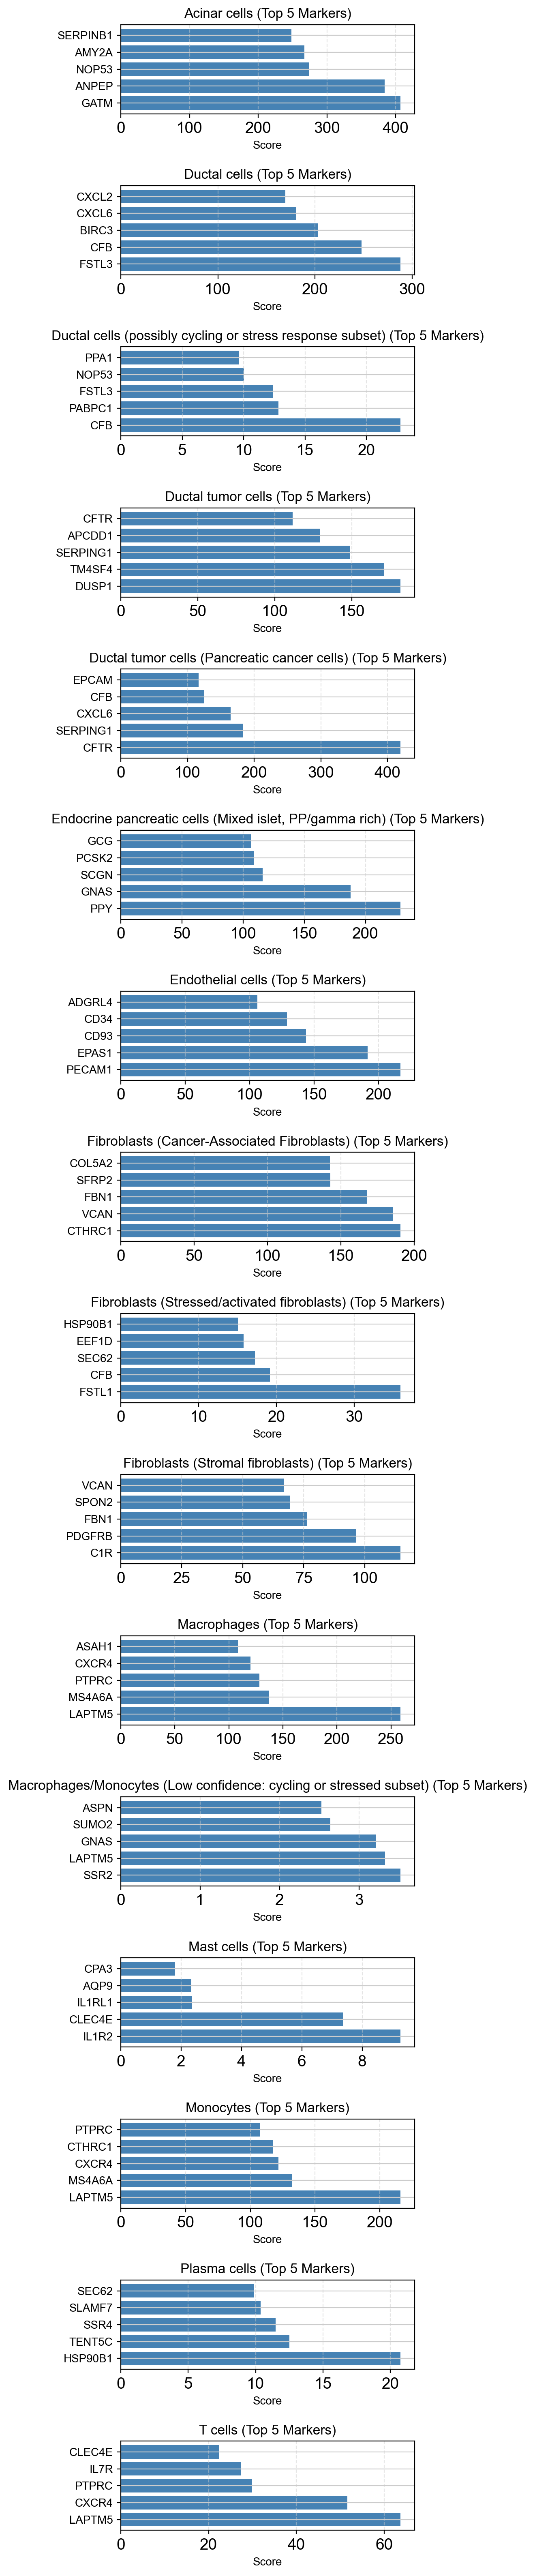

In [8]:
# Cell 8: Plot Top Genes
# ----------------------

plot_top_genes_by_celltype(
    adata_pred,
    key_for_rank="rank_genes_by_pred",
    n_genes=5,
    figsize_per_cell=(5, 2),
    title_suffix="(Top 5 Markers)"
)


### (Optional) Create a Wide Table of Top Genes + Scores per Cell Type

If you prefer a single table with columns `gene_1, score_1, gene_2, score_2, …`, you can pivot `df_top`.

In [9]:
# Cell 9: Pivot to Wide Format Table (Optional)
# --------------------------------------------

table_rows = []
for ct in df_top["cell_type"].unique():
    sub = df_top[df_top["cell_type"] == ct].reset_index(drop=True)
    row = {"cell_type": ct}
    for i in range(len(sub)):
        row[f"gene_{i+1}"] = sub.loc[i, "gene"]
        row[f"score_{i+1}"] = sub.loc[i, "score"]
    table_rows.append(row)

df_wide = pd.DataFrame(table_rows).set_index("cell_type")
df_wide


,gene_1,score_1,gene_2,score_2,gene_3,score_3,gene_4,score_4,gene_5,score_5
cell_type,,,,,,,,,,
Acinar cells,GATM,407.114899,ANPEP,384.091736,NOP53,273.407166,AMY2A,266.942566,SERPINB1,248.194031
Ductal cells,FSTL3,288.090363,CFB,248.013107,BIRC3,202.803223,CXCL6,180.395004,CXCL2,169.497711
Ductal cells (possibly cycling or stress response subset),CFB,22.770863,PABPC1,12.819361,FSTL3,12.396651,NOP53,10.032028,PPA1,9.630423
Ductal tumor cells,DUSP1,181.503357,TM4SF4,171.026993,SERPING1,148.446136,APCDD1,129.346802,CFTR,111.592918
Ductal tumor cells (Pancreatic cancer cells),CFTR,419.470856,SERPING1,183.027603,CXCL6,164.629364,CFB,124.497681,EPCAM,116.586014
"Endocrine pancreatic cells (Mixed islet, PP/gamma rich)",PPY,228.728165,GNAS,187.790543,SCGN,116.084122,PCSK2,108.983467,GCG,106.417435
Endothelial cells,PECAM1,217.001297,EPAS1,191.551712,CD93,143.788177,CD34,128.976425,ADGRL4,105.829552
Fibroblasts (Cancer-Associated Fibroblasts),CTHRC1,190.694672,VCAN,185.751419,FBN1,168.104401,SFRP2,142.905212,COL5A2,142.428940
Fibroblasts (Stressed/activated fibroblasts),FSTL1,35.934822,CFB,19.179018,SEC62,17.207682,EEF1D,15.786576,HSP90B1,15.046872


---
## Summary

In this tutorial, you have:
1. Loaded a Xenium spatial transcriptomics dataset.
2. Performed clustering with Scanpy (Leiden) and extracted top marker genes.
3. Used an LLM (e.g. OpenAI) to assign cell-type labels automatically.
4. Visualized UMAP colored by predicted cell types.
5. Re-ranked marker genes by predicted cell type and visualized them.

You can replace the dataset or customize `assign_params` / `n_genes` / the LLM model as needed. For large datasets or custom LLM backends, adjust the caching or timeout settings in `tic.annotation`.